<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [16]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-05-08 22:51:30--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.5’

survey-data.csv.5   100%[===================>] 152.13M  37.6MB/s    in 4.2s    

2026-05-08 22:51:36 (36.3 MB/s) - ‘survey-data.csv.5’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [17]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [18]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [19]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [20]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [21]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [22]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [23]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [24]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


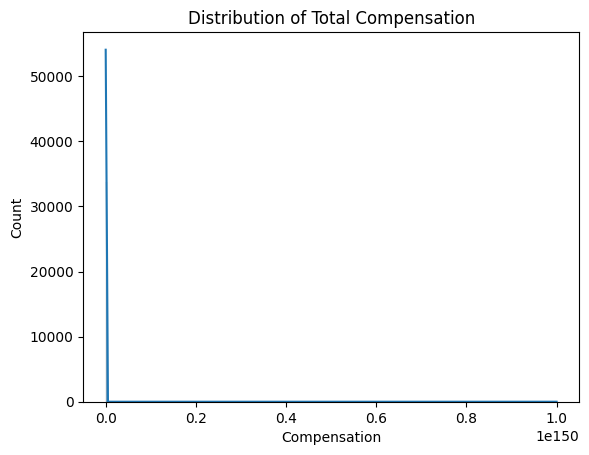

In [25]:
## Write your code here
!pip install seaborn
import seaborn as sns
QUERY = """
SELECT CompTotal
FROM main
"""

df_hist = pd.read_sql_query(QUERY, conn)

sns.histplot(df_hist['CompTotal'], kde=True)
plt.title('Distribution of Total Compensation')
plt.xlabel('Compensation')
plt.ylabel('Count')
plt.show()

**Box Plots**

Plot a box plot of Age.


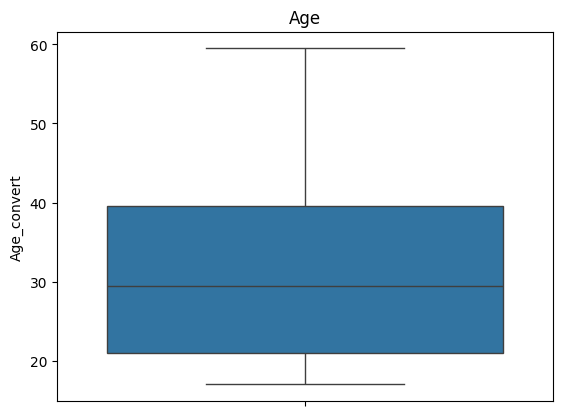

In [26]:
## Write your code here
QUERY = """
SELECT Age
FROM main
"""

df_box = pd.read_sql_query(QUERY, conn)
def convert_age(age):
    if isinstance(age, str):
        age = age.lower().replace("years old", '').strip()
        if "under" in age:
            return 17
        elif '-' in age:
            parts = age.split('-')
            return (int(parts[0]) + int(parts[1])) / 2
    return None
        
   

df_box['Age_convert'] = df_box['Age'].apply(convert_age)
            
sns.boxplot(df_box['Age_convert'])
plt.title('Age')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


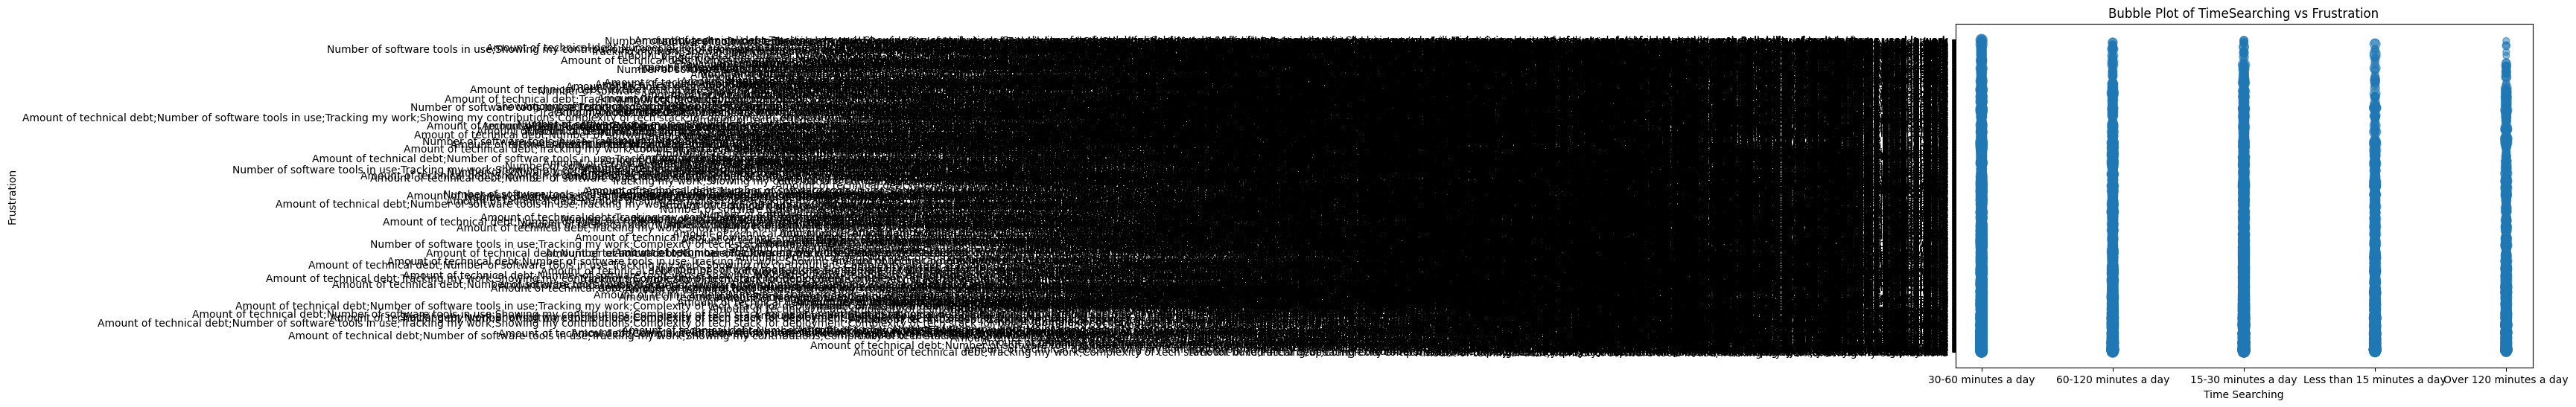

In [27]:
## Write your code here
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
"""

df_bubble = pd.read_sql_query(QUERY, conn)


# Function to convert Age into numbers

def convert_age(age):

    if isinstance(age, str):

        age = age.lower().replace("years old", "").strip()

        if "under" in age:
            return 17

        elif "-" in age:

            parts = age.split("-")

            return (int(parts[0]) + int(parts[1])) / 2

    return None


# Apply function on Age column

df_bubble['Age_convert'] = df_bubble['Age'].apply(convert_age)


# Remove rows with missing values

df_bubble = df_bubble.dropna(
    subset=['TimeSearching', 'Frustration', 'Age_convert']
)


# Create figure size

plt.figure(figsize=(10,6))


# Create bubble plot

plt.scatter(
    df_bubble['TimeSearching'],
    df_bubble['Frustration'],
    s=df_bubble['Age_convert'] * 2,
    alpha=0.5
)


# Add labels

plt.xlabel("Time Searching")

plt.ylabel("Frustration")


# Add title

plt.title("Bubble Plot of TimeSearching vs Frustration")


# Show graph

plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


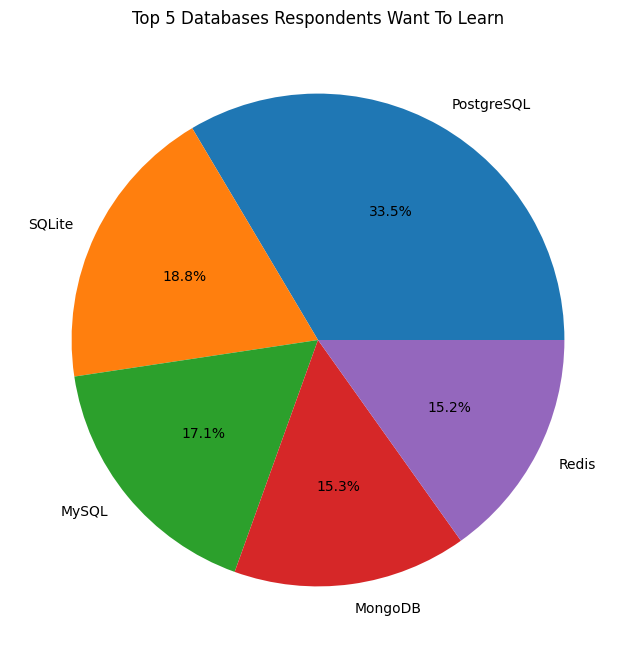

In [28]:
## Write your code here
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
"""

df_pie = pd.read_sql_query(QUERY, conn)


# Remove missing values and split databases

dbs = df_pie[
    'DatabaseWantToWorkWith'
].dropna().str.split(';')


# Convert lists into rows

dbs = dbs.explode()


# Count frequencies

top5 = dbs.value_counts().head(5)


# Create pie chart

plt.figure(figsize=(8,8))

top5.plot(
    kind='pie',
    autopct='%1.1f%%'
)


# Add title

plt.title("Top 5 Databases Respondents Want To Learn")


# Remove y-label

plt.ylabel("")


# Show chart

plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


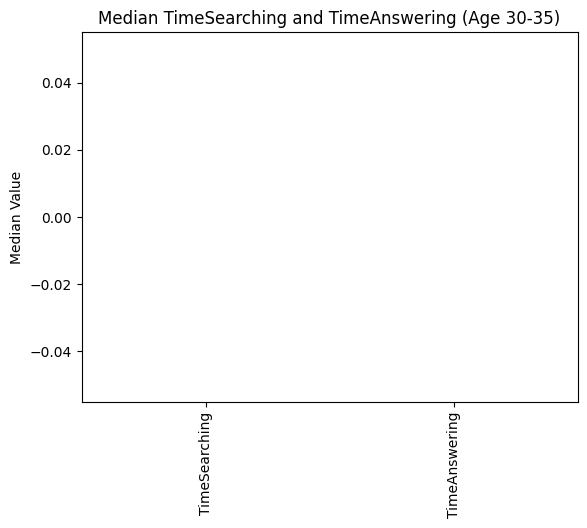

In [31]:
# SQL query

QUERY = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
"""


# Read data from database

df_stack = pd.read_sql_query(QUERY, conn)


# Function to convert Age into numeric values

def convert_age(age):

    # Check if value is string

    if isinstance(age, str):

        # Convert to lowercase and clean text

        age = age.lower().replace("years old", "").strip()

        # Handle "Under 18"

        if "under" in age:
            return 17

        # Handle ranges like 25-34

        elif "-" in age:

            parts = age.split("-")

            return (int(parts[0]) + int(parts[1])) / 2

    return None


# Create numeric Age column

df_stack['Age_convert'] = df_stack['Age'].apply(convert_age)


# Keep only ages between 30 and 35

age_filtered = df_stack[
    (df_stack['Age_convert'] >= 30) &
    (df_stack['Age_convert'] <= 35)
].copy()


# Convert TimeSearching into numeric

age_filtered['TimeSearching'] = pd.to_numeric(
    age_filtered['TimeSearching'],
    errors='coerce'
)


# Convert TimeAnswering into numeric

age_filtered['TimeAnswering'] = pd.to_numeric(
    age_filtered['TimeAnswering'],
    errors='coerce'
)


# Remove rows with missing values

age_filtered = age_filtered.dropna(
    subset=['TimeSearching', 'TimeAnswering']
)


# Calculate median values

median_values = age_filtered[
    ['TimeSearching', 'TimeAnswering']
].median()


# Create stacked bar chart

median_values.plot(
    kind='bar',
    stacked=True
)


# Add title

plt.title(
    "Median TimeSearching and TimeAnswering (Age 30-35)"
)


# Add y-axis label

plt.ylabel("Median Value")


# Show chart

plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


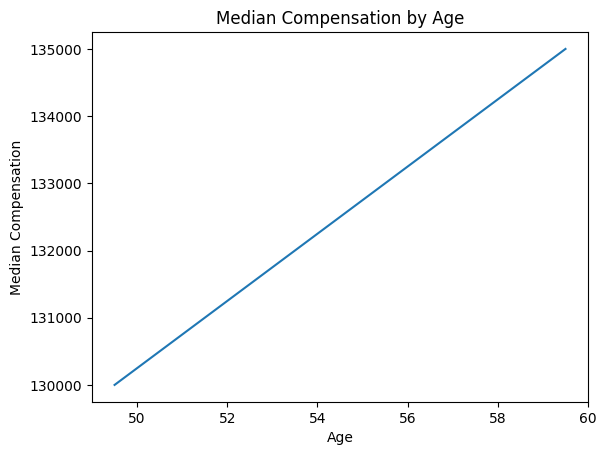

In [32]:
## Write your code here
# SQL query

QUERY = """
SELECT Age, CompTotal
FROM main
"""


# Read SQL query

df_line = pd.read_sql_query(QUERY, conn)


# Function to convert Age

def convert_age(age):

    if isinstance(age, str):

        age = age.lower().replace("years old", "").strip()

        if "under" in age:
            return 17

        elif "-" in age:

            parts = age.split("-")

            return (int(parts[0]) + int(parts[1])) / 2

    return None


# Create numeric Age column

df_line['Age_convert'] = df_line['Age'].apply(convert_age)


# Convert compensation into numeric

df_line['CompTotal'] = pd.to_numeric(
    df_line['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_line = df_line.dropna(
    subset=['Age_convert', 'CompTotal']
)


# Keep ages between 45 and 60

age_filtered = df_line[
    (df_line['Age_convert'] >= 45) &
    (df_line['Age_convert'] <= 60)
]


# Group by age

line_data = age_filtered.groupby(
    'Age_convert'
)['CompTotal'].median()


# Create line chart

line_data.plot(kind='line')


# Add title

plt.title("Median Compensation by Age")


# Axis labels

plt.xlabel("Age")

plt.ylabel("Median Compensation")


# Show graph

plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


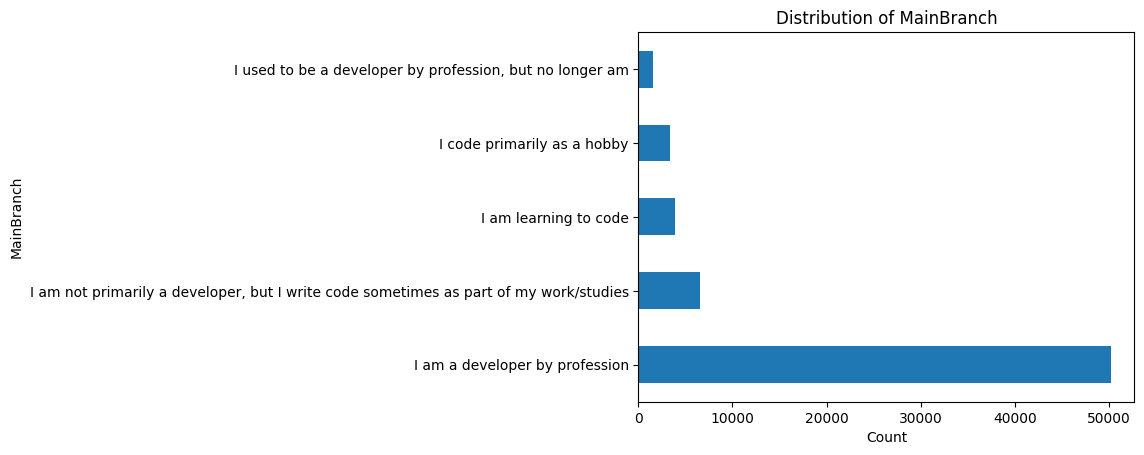

In [33]:
## Write your code here
# SQL query

QUERY = """
SELECT MainBranch
FROM main
"""


# Read SQL query

df_bar = pd.read_sql_query(QUERY, conn)


# Count category frequencies

branch_counts = df_bar[
    'MainBranch'
].value_counts()


# Create horizontal bar chart

branch_counts.plot(kind='barh')


# Add title

plt.title("Distribution of MainBranch")


# Add labels

plt.xlabel("Count")

plt.ylabel("MainBranch")


# Show graph

plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [34]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
